<a href="https://colab.research.google.com/github/imriyamandal/Learning-ML/blob/main/ML_preparing_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

preparing **DATASET**

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df['Travelalone'] = np.where((df['SibSp'] + df['Parch']) > 0, 0, 1).astype('uint8')

In [ ]:
print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Travelalone'],
      dtype='object')


In [ ]:
df1 = df.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], axis = 1)

In [ ]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Age'].fillna(df1['Age'].median(skipna=True), inplace=True)

/tmp/ipykernel_2695/2169829194.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df1['Age'].median(skipna=True), inplace=True)


In [ ]:
df1.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Travelalone
0,0,3,male,22.0,7.2500,S,0
1,1,1,female,38.0,71.2833,C,0
2,1,3,female,26.0,7.9250,S,1
3,1,1,female,35.0,53.1000,S,0
4,0,3,male,35.0,8.0500,S,1


In [ ]:
df_titanic = pd.get_dummies(df1, columns=['Pclass','Embarked','Sex'], drop_first=True)

In [ ]:
df_titanic.head()

,Survived,Age,Fare,Travelalone,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Sex_male
0,0,22.0,7.2500,0,False,True,False,True,True
1,1,38.0,71.2833,0,False,False,False,False,False
2,1,26.0,7.9250,1,False,True,False,True,False
3,1,35.0,53.1000,0,False,False,False,True,False
4,0,35.0,8.0500,1,False,True,False,True,True


In [ ]:
X = df_titanic.drop(['Survived'], axis=1)
y = df_titanic['Survived']

Scikit-learn preprocessing library

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
trans_MM = MinMaxScaler()
trans_SS = StandardScaler()

In [ ]:
df_MM = trans_MM.fit_transform(X)
pd.DataFrame(df_MM)

,0,1,2,3,4,5,6,7
0,0.271174,0.014151,0.0,0.0,1.0,0.0,1.0,1.0
1,0.472229,0.139136,0.0,0.0,0.0,0.0,0.0,0.0
2,0.321438,0.015469,1.0,0.0,1.0,0.0,1.0,0.0
3,0.434531,0.103644,0.0,0.0,0.0,0.0,1.0,0.0
4,0.434531,0.015713,1.0,0.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...
886,0.334004,0.025374,1.0,1.0,0.0,0.0,1.0,1.0
887,0.233476,0.058556,1.0,0.0,0.0,0.0,1.0,0.0
888,NaN,0.045771,0.0,0.0,1.0,0.0,1.0,0.0
889,0.321438,0.058556,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df_SS = trans_SS.fit_transform(X)
pd.DataFrame(df_SS)

,0,1,2,3,4,5,6,7
0,-0.530377,-0.502445,-1.231645,-0.510152,0.902587,-0.307562,0.619306,0.737695
1,0.571831,0.786845,-1.231645,-0.510152,-1.107926,-0.307562,-1.614710,-1.355574
2,-0.254825,-0.488854,0.811922,-0.510152,0.902587,-0.307562,0.619306,-1.355574
3,0.365167,0.420730,-1.231645,-0.510152,-1.107926,-0.307562,0.619306,-1.355574
4,0.365167,-0.486337,0.811922,-0.510152,0.902587,-0.307562,0.619306,0.737695
...,...,...,...,...,...,...,...,...
886,-0.185937,-0.386671,0.811922,1.960202,-1.107926,-0.307562,0.619306,0.737695
887,-0.737041,-0.044381,0.811922,-0.510152,-1.107926,-0.307562,0.619306,-1.355574
888,NaN,-0.176263,-1.231645,-0.510152,0.902587,-0.307562,0.619306,-1.355574
889,-0.254825,-0.044381,0.811922,-0.510152,-1.107926,-0.307562,-1.614710,0.737695


Overfitting and Underfitting  

In [48]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot

In [50]:
X, y = make_classification(n_samples=9000, n_features=18, n_informative=4, n_redundant=12, random_state=4)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [52]:
train_scores, test_scores = list(), list()

In [53]:
values = [i for i in range(1, 21)]

In [56]:
for i in values:
    model = DecisionTreeClassifier(max_depth=i)

    model.fit(X_train, y_train)

    train_yhat = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_yhat)

    test_yhat = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_yhat)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

    print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1, train: 0.838, test: 0.832
>2, train: 0.852, test: 0.849
>3, train: 0.871, test: 0.864
>4, train: 0.895, test: 0.885
>5, train: 0.907, test: 0.900
>6, train: 0.930, test: 0.916
>7, train: 0.947, test: 0.925
>8, train: 0.959, test: 0.930
>9, train: 0.972, test: 0.936
>10, train: 0.978, test: 0.933
>11, train: 0.987, test: 0.937
>12, train: 0.990, test: 0.938
>13, train: 0.993, test: 0.936
>14, train: 0.995, test: 0.934
>15, train: 0.997, test: 0.934
>16, train: 0.998, test: 0.932
>17, train: 0.999, test: 0.932
>18, train: 0.999, test: 0.934
>19, train: 0.999, test: 0.935
>20, train: 1.000, test: 0.933


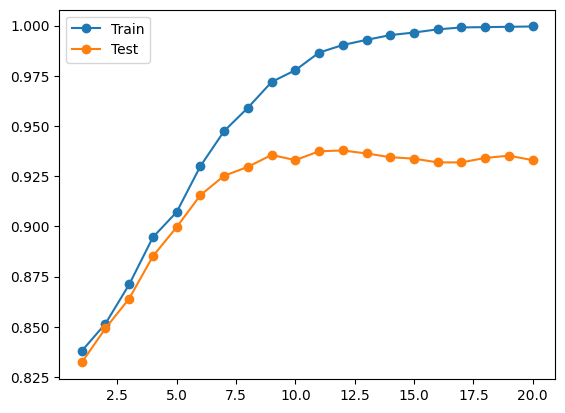

In [57]:
pyplot.plot(values, train_scores, '-o', label='Train')
pyplot.plot(values, test_scores, '-o', label='Test')
pyplot.legend()
pyplot.show()

In [58]:
from sklearn.model_selection import GridSearchCV

In [59]:
param_grid = {'criterion' : ['gini', 'entropy'], 'max_depth':[2, 4, 6, 10, 20], 'min_samples_split':[5, 10, 20, 50, 100]}
clf = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=3, n_jobs = -1, scoring = "accuracy")
clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 10, 20],
                         'min_samples_split': [5, 10, 20, 50, 100]},
             scoring='accuracy')

In [60]:
clf.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=10)

In [61]:
DecisionTreeClassifier(criterion = 'entropy', max_depth = 10, min_samples_split = 5)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_split=5)

In [62]:
print(accuracy_score(y_train, clf.best_estimator_.predict(X_train)))
print(accuracy_score(y_test, clf.best_estimator_.predict(X_test)))

0.9750793650793651
0.9355555555555556
